# shapefile to .map

### description

this notebooks creates a clonemap and landmask from provided shapefile/shapefiles for use in PCRGLOBWB modelling. Tested using GRDC station-catchment shapefiles. 

### Requirements

This notebook requires a conda environment with PCRaster.

### Installation

Create and set up the environment:

```bash
conda create -n pcraster_env python=3.10
conda activate pcraster_env

mamba install -c conda-forge \
  pcraster \
  geopandas \
  rasterio \
  xarray \
  numpy \
  matplotlib \
  jupyter \
  ipykernel\
  fiona

python -m ipykernel install --user --name pcraster_env --display-name "Python (pcraster)"
```

### Usage

* Start Jupyter Notebook
* Select the kernel: **Python (pcraster)**




In [1]:
# check if installed correctly

import pcraster as pcr
import pcraster.matplotlib as pcrplt

print("PCRaster works!")

PCRaster works!


In [2]:
import subprocess
from collections.abc import Sequence
from pathlib import Path
from typing import Union

import geopandas as gpd
import numpy as np
import pandas as pd
import pcraster.numpy_operations as pcrnp
from rasterio.features import rasterize
from rasterio.transform import from_origin

# helper functions

In [3]:
def create_clonemap(lonmin, latmin, lonmax, latmax, forcing_resolution, catchment):
    """Create new clonemap compatible with forcing data resolution.

    Made by Rolf Hut and Mark Melotto?, slightly modified by Andre van der Veen
    """
    dlon = lonmax - lonmin
    dlat = latmax - latmin

    msg = (
        "The clonemap extent divided by the forcing resolution must yield"
        " an integer number of grid cells."
    )
    assert (
        dlon % forcing_resolution == 0
    ), f"Longitudes not compatible. {msg} Currently = {dlon % forcing_resolution}"
    assert (
        dlat % forcing_resolution == 0
    ), f"Latitudes not compatible. {msg} Currently = {dlat % forcing_resolution}"

    clonemap_dir = "/data/shared/parameter-sets/pcrglobwb_global/global_05min/cloneMaps"  # location of global clonemap on /data/shared, requires permission?
    globalclonemap = clonemap_dir + "/clone_global_05min.map"
    outputclonemap = f"./{catchment.lower()}_05min_clone.map"  # copy to clonemap dir after ensuring it is correct

    subprocess.call(
        f"gdal_translate -of PCRaster {globalclonemap} -projwin "
        f"{lonmin} {latmax} {lonmax} {latmin} {outputclonemap}",
        shell=True,
    )
    return outputclonemap

In [ ]:
def shapefile_to_mask(clonemap, shapefile, output_mask, mv=-9999):
    """
    Create a PCRaster mask based on a shapefile and existing cloneMap.
    Inside shapefile values set to True, outside of the shapefile to 'missing values'
    """
    # set original clonemap as clonemap to ensure grids align, read Rasterinfo from cloneMap
    pcr.setclone(clonemap)
    clone = pcr.clone()
    rows = clone.nrRows()
    cols = clone.nrCols()
    cellsize = clone.cellSize()
    xUL = clone.west()  # left coordinate
    yUL = clone.north()  # top coordinate

    # Read shapefile geometries
    gdf = gpd.read_file(shapefile)

    shapes = [(geom, 1) for geom in gdf.geometry]

    # make numpy raster with values outside shape to np.nan
    transform = from_origin(xUL, yUL, cellsize, cellsize)  # square cells so xsize, ysize = cellsize
    raster = rasterize(
        shapes, out_shape=(rows, cols), transform=transform, fill=np.nan, dtype="float32"
    )

    # Convert to PCRaster map, with np.nan to missing values
    arr = np.where(np.isnan(raster), mv, raster)
    pcr_map = pcrnp.numpy2pcr(pcr.Scalar, arr, mv)

    # make sure inside shapefile is True
    pcr_map = pcr_map == 1

    # save output
    pcr.report(pcr_map, output_mask)

    print(f"Mask saved as {output_mask}")
    return output_mask

In [5]:
def shapefiles_to_mask(clonemap, shapefiles, output_mask, mv=-9999):
    """
    Create a PCRaster mask based on several shapefiles and existing cloneMap.
    Inside shapefile values set to True, outside of the shipefile to 'missing values'
    """
    # set original clonemap as clonemap to ensure grids align, read Rasterinfo from cloneMap
    pcr.setclone(clonemap)
    clone = pcr.clone()
    rows = clone.nrRows()
    cols = clone.nrCols()
    cellsize = clone.cellSize()
    xUL = clone.west()  # left coordinate
    yUL = clone.north()  # top coordinate

    # Read shapefile geometries ---
    gdfs = [gpd.read_file(shp) for shp in shapefiles]
    gdf = gpd.GeoDataFrame(pd.concat(gdfs, ignore_index=True), crs=gdfs[0].crs)

    shapes = [(geom, 1) for geom in gdf.geometry]

    # make numpy raster with values outside shape to np.nan
    transform = from_origin(xUL, yUL, cellsize, cellsize)  # square cells so xsize, ysize = cellsize
    raster = rasterize(
        shapes, out_shape=(rows, cols), transform=transform, fill=np.nan, dtype="float32"
    )

    # Convert to PCRaster map, with np.nan to missing values
    arr = np.where(np.isnan(raster), mv, raster)
    pcr_map = pcrnp.numpy2pcr(pcr.Scalar, arr, mv)

    # make sure inside shapefile is True
    pcr_map = pcr_map == 1

    # save output
    pcr.report(pcr_map, output_mask)

    print(f"Mask saved as {output_mask}")
    return output_mask

In [6]:
def get_integer_multiple_bounds(
    shapefiles: Union[str, Path, Sequence[Union[str, Path]]],
    multiple: int = 3,
):
    """
    docstring
    docstring
    docstring
    """

    # --- normalize input to list ---
    if isinstance(shapefiles, (str, Path)):
        shapefiles = [shapefiles]

    # --- read & combine ---
    gdfs = [gpd.read_file(shp) for shp in shapefiles]
    gdf = gpd.GeoDataFrame(
        pd.concat(gdfs, ignore_index=True),
        crs=gdfs[0].crs,
    )

    # --- original bounds ---
    lon_min, lat_min, lon_max, lat_max = gdf.total_bounds

    # --- convert to integer bounds ---
    lon_min_i = int(np.floor(lon_min))
    lat_min_i = int(np.floor(lat_min))
    lon_max_i = int(np.ceil(lon_max))
    lat_max_i = int(np.ceil(lat_max))

    # --- helper to expand to multiple ---
    def expand_to_multiple(min_val, max_val, multiple):
        extent = max_val - min_val
        remainder = extent % multiple
        if remainder != 0:
            max_val += multiple - remainder
        return min_val, max_val

    lon_min_f, lon_max_f = expand_to_multiple(lon_min_i, lon_max_i, multiple)
    lat_min_f, lat_max_f = expand_to_multiple(lat_min_i, lat_max_i, multiple)

    return lon_min_f, lat_min_f, lon_max_f, lat_max_f

# .Map Generation Testing - Aral Sea files

make sure the extend of the shapefiles is not larger than the provided meteorological forcing data 

In [7]:
# Catchment bounding boxes
clonemap_extents = {
    "aral_sea_test": {"latitude": (32, 47), "longitude": (52, 79)},
}


forcing_resolution = 0.75
for catchment, extents in clonemap_extents.items():
    latmin, latmax = extents["latitude"]
    lonmin, lonmax = extents["longitude"]
    print(
        create_clonemap(
            lonmin, latmin, lonmax, latmax, forcing_resolution, catchment
        )  # makes clonemap with manual sizing input
    )

Input file size is 4320, 2160
0...10...20...30...40...50...60...70...80...90...100 - done.
./aral_sea_test_05min_clone.map


In [8]:
shapefile_to_mask(
    "aral_sea_test_05min_clone.map",  # existing clonemap
    "../../data/shapefiles/Kazalinsk_GRDC/Kazalinsk_GRDC.shp",  # relative path to shapefile
    "aral_sea_test_05min_Kazalinsk_mask.map",  # name of landmask to be generated
)

Mask saved as aral_sea_test_05min_Kazalinsk_mask.map


'aral_sea_test_05min_Kazalinsk_mask.map'

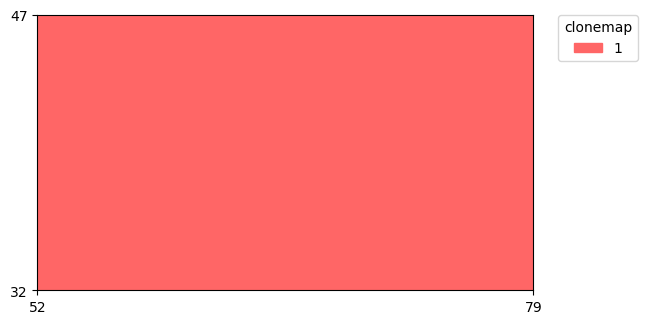

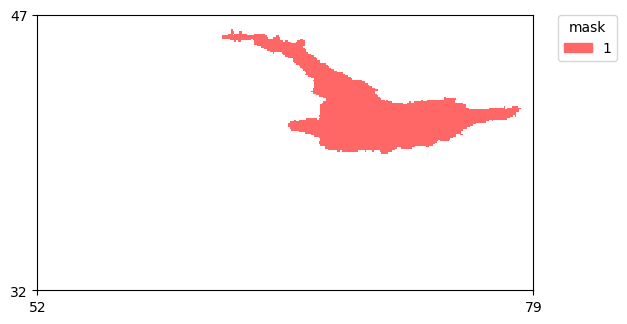

In [9]:
# read clonemap and landmask
clonemap_file = "aral_sea_test_05min_clone.map"
mask_file = "aral_sea_test_05min_Kazalinsk_mask.map"

clonemap = pcr.readmap(clonemap_file)
mask = pcr.readmap(mask_file)

# --- 2. Plot clonemap ---
pcrplt.plot(clonemap)  # , title="Clonemap") #, filename="clonemap_plot.png")

# --- 3. Plot shapefile mask ---
pcrplt.plot(
    mask
)  # , title="Shapefile Mask (TRUE inside, MV outside)") #, filename="mask_plot.png")

## Make everything - Aral Sea files

In [10]:
# import file
shapefile_path = "../../data/shapefiles/Chatly_GRDC/Chatly_GRDC.shp"
shapefile_path_2 = "../../data/shapefiles/Kazalinsk_GRDC/Kazalinsk_GRDC.shp"

# Convert to Path object
shp_path = Path(shapefile_path)

# Catchment = name of shapefile in lowercase
catchment = shp_path.stem.lower()

print(catchment)

chatly_grdc


In [11]:
gdf = gpd.read_file(shapefile_path)

# get lat lon values from shapefile
lon_min, lat_min, lon_max, lat_max = gdf.total_bounds
print("Original bounds:", lon_min, lat_min, lon_max, lat_max)

# convert to integer values (needed for PCRGLOBWB)
lon_min_i = int(np.floor(lon_min))
lat_min_i = int(np.floor(lat_min))
lon_max_i = int(np.ceil(lon_max))
lat_max_i = int(np.ceil(lat_max))


# helper function to set max values to multiples of 3 degrees to satisfy lat/lon = int and number of steps = int
def expand_to_multiple(min_val, max_val, multiple):
    extent = max_val - min_val
    remainder = extent % multiple
    if remainder != 0:
        max_val += multiple - remainder
    return min_val, max_val


# use helper function
lon_min_f, lon_max_f = expand_to_multiple(lon_min_i, lon_max_i, 3)
lat_min_f, lat_max_f = expand_to_multiple(lat_min_i, lat_max_i, 3)

print("Final bounds:", lon_min_f, lat_min_f, lon_max_f, lat_max_f)
print("Extent:", lon_max_f - lon_min_f, lat_max_f - lat_min_f)

Original bounds: 59.725 34.4833 75.1542 42.4542
Final bounds: 59 34 77 43
Extent: 18 9


In [12]:
forcing_resolution = 0.75
create_clonemap(lon_min_f, lat_min_f, lon_max_f, lat_max_f, forcing_resolution, catchment)

# Existing clonemap
clonemap_file = f"{catchment}_05min_clone.map"

# Output mask file
mask_file = f"{catchment}_05min_mask.map"

shapefile_to_mask(
    clonemap_file,  # existing clonemap
    shapefile_path,
    mask_file,  # name of landmask to be generated
)

Input file size is 4320, 2160
0...10...20...30...40...50...60...70...80...90...100 - done.
Mask saved as chatly_grdc_05min_mask.map


'chatly_grdc_05min_mask.map'

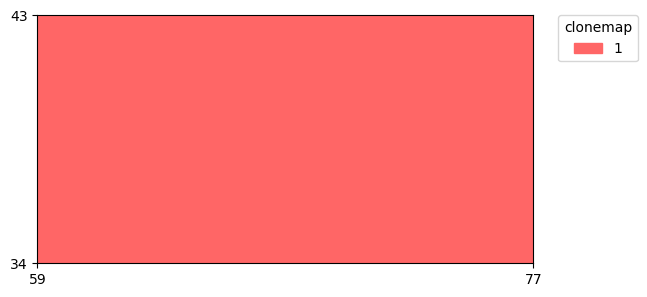

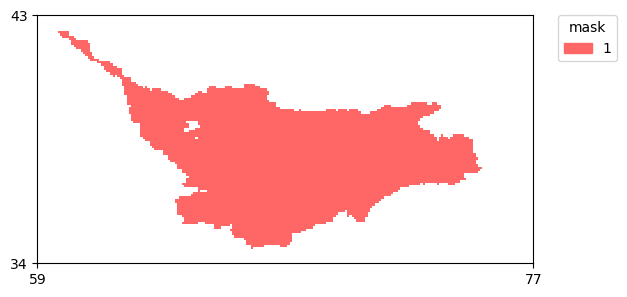

In [13]:
clonemap = pcr.readmap(clonemap_file)
mask = pcr.readmap(mask_file)

# plot clonemap
pcrplt.plot(clonemap)  # , title="Clonemap") #, filename="clonemap_plot.png")

# plot landmask
pcrplt.plot(mask)

In [14]:
lon_min_f, lat_min_f, lon_max_f, lat_max_f = get_integer_multiple_bounds(
    [shapefile_path, shapefile_path_2],
    multiple=3,
)
print(lon_min_f, lat_min_f, lon_max_f, lat_max_f)

59 34 80 49


In [15]:
forcing_resolution = 0.75
catchment2 = "aral_basin_AD_SD_rivers"
catchment2 = catchment2.lower()
create_clonemap(lon_min_f, lat_min_f, lon_max_f, lat_max_f, forcing_resolution, catchment2)

Input file size is 4320, 2160
0...10...20...30...40...50...60...70...80...90...100 - done.


'./aral_basin_ad_sd_rivers_05min_clone.map'

In [16]:
# Existing clonemap
clonemap_file = f"{catchment2}_05min_clone.map"

# Output mask file
mask_file = f"{catchment2}_05min_mask.map"

shapefiles_to_mask(
    clonemap_file,  # existing clonemap
    [shapefile_path, shapefile_path_2],
    mask_file,  # name of landmask to be generated
)

Mask saved as aral_basin_ad_sd_rivers_05min_mask.map


'aral_basin_ad_sd_rivers_05min_mask.map'

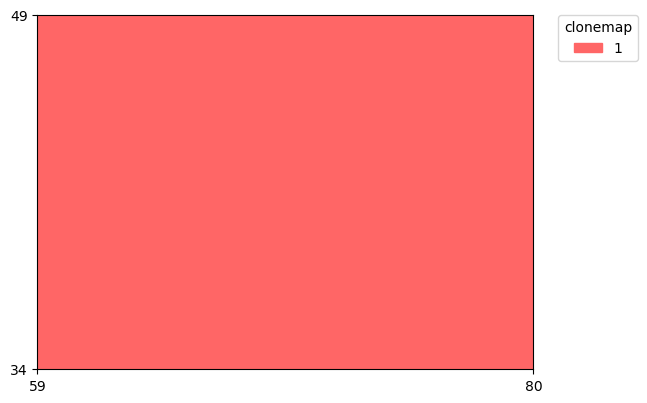

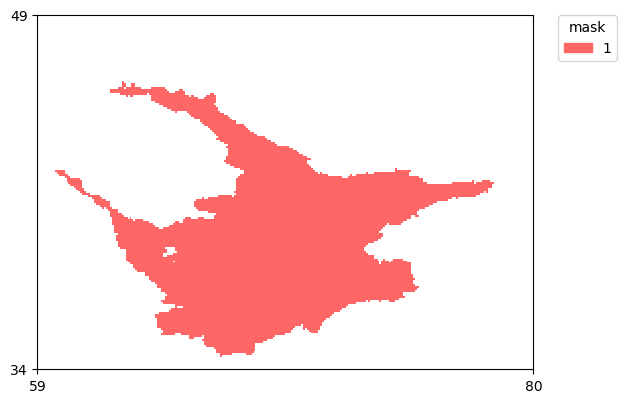

In [17]:
clonemap = pcr.readmap(clonemap_file)
mask = pcr.readmap(mask_file)

# plot clonemap
pcrplt.plot(clonemap)  # , title="Clonemap") #, filename="clonemap_plot.png")

# plot landmask
pcrplt.plot(mask)

# some more testing files

West & East

In [10]:
shp_id1 = "shapefiles_converter/id_1.shp"
shp_id2 = "shapefiles_converter/id_2.shp"
shp_id5 = "shapefiles_converter/id_5.shp"

In [11]:
lon_min_f, lat_min_f, lon_max_f, lat_max_f = get_integer_multiple_bounds(
    [shp_id1, shp_id2, shp_id5],
    multiple=3,
)
print(lon_min_f, lat_min_f, lon_max_f, lat_max_f)

-5 45 7 54


In [13]:
forcing_resolution = 0.75
catchment_test = "test_England_France"
catchment_test = catchment_test.lower()
create_clonemap(lon_min_f, lat_min_f, lon_max_f, lat_max_f, forcing_resolution, catchment_test)

Input file size is 4320, 2160
0...10...20...30...40...50...60...70...80...90...100 - done.


'./test_england_france_05min_clone.map'

In [14]:
# Existing clonemap
clonemap_file = f"{catchment_test}_05min_clone.map"

# Output mask file
mask_file = f"{catchment_test}_05min_mask.map"

shapefiles_to_mask(
    clonemap_file,  # existing clonemap
    [shp_id1, shp_id2, shp_id5],
    mask_file,  # name of landmask to be generated
)

Mask saved as test_england_france_05min_mask.map


'test_england_france_05min_mask.map'

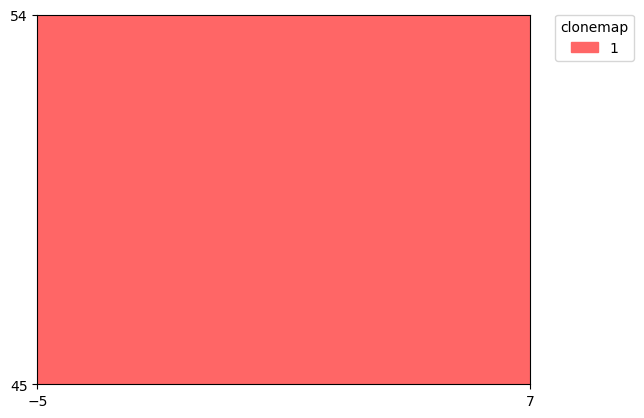

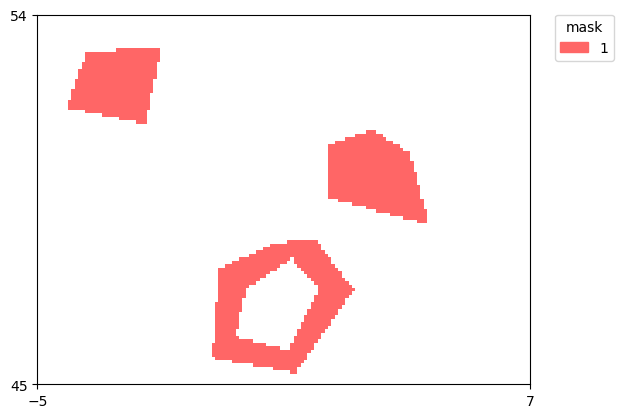

In [15]:
clonemap = pcr.readmap(clonemap_file)
mask = pcr.readmap(mask_file)

# plot clonemap
pcrplt.plot(clonemap)  # , title="Clonemap") #, filename="clonemap_plot.png")

# plot landmask
pcrplt.plot(mask)